In [2]:
import pandas as pd

df = pd.read_csv('./data/GOOG.csv')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.676899,51.693783,47.669952,49.845802,49.845802,44994500
1,2004-08-20,50.178635,54.187561,49.925285,53.805050,53.805050,23005800
2,2004-08-23,55.017166,56.373344,54.172661,54.346527,54.346527,18393200
3,2004-08-24,55.260582,55.439419,51.450363,52.096165,52.096165,15361800
4,2004-08-25,52.140873,53.651051,51.604362,52.657513,52.657513,9257400


In [3]:
# We load the Google stock data into a DataFrame
google_stock = pd.read_csv('./data/GOOG.csv', usecols =['Date', 'Adj Close'], index_col=['Date'], parse_dates=True)

# We load the Apple stock data into a DataFrame
apple_stock = pd.read_csv('./data/AAPL.csv', usecols =['Date', 'Adj Close'], index_col=['Date'], parse_dates=True)

# We load the Amazon stock data into a DataFrame
amazon_stock = pd.read_csv('./data/AMZN.csv', usecols =['Date', 'Adj Close'], index_col=['Date'], parse_dates=True)

In [4]:
# We create calendar dates between '2000-01-01' and  '2016-12-31'
dates = pd.date_range('2000-01-01', '2016-12-31')

# We create and empty DataFrame that uses the above dates as indices
all_stocks = pd.DataFrame(index = dates)

print(dates)

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08',
               '2000-01-09', '2000-01-10',
               ...
               '2016-12-22', '2016-12-23', '2016-12-24', '2016-12-25',
               '2016-12-26', '2016-12-27', '2016-12-28', '2016-12-29',
               '2016-12-30', '2016-12-31'],
              dtype='datetime64[us]', length=6210, freq='D')


In [5]:
# Change the Adj Close column label to Google
google_stock = google_stock.rename(columns={'Adj Close':'google_stock_adj_close'})

# Change the Adj Close column label to Apple
apple_stock = apple_stock.rename(columns={'Adj Close':'apple_stock_adj_close'})

# Change the Adj Close column label to Amazon
amazon_stock = amazon_stock.rename(columns={'Adj Close':'amazon_stock_adj_close'})

In [6]:
# We display the google_stock DataFrame
google_stock.head()

,google_stock_adj_close
Date,
2004-08-19,49.845802
2004-08-20,53.805050
2004-08-23,54.346527
2004-08-24,52.096165
2004-08-25,52.657513


In [7]:
# We join the Google stock to all_stocks
all_stocks = all_stocks.join(google_stock)

# We join the Apple stock to all_stocks
all_stocks = all_stocks.join(apple_stock)

# We join the Amazon stock to all_stocks
all_stocks = all_stocks.join(amazon_stock)

In [8]:
# We display the all_stocks DataFrame
all_stocks.head()

,google_stock_adj_close,apple_stock_adj_close,amazon_stock_adj_close
2000-01-01,NaN,NaN,NaN
2000-01-02,NaN,NaN,NaN
2000-01-03,NaN,3.596616,89.3750
2000-01-04,NaN,3.293384,81.9375
2000-01-05,NaN,3.341579,69.7500


In [9]:
# Describe the all_stocks DataFrame
all_stocks.describe()

,google_stock_adj_close,apple_stock_adj_close,amazon_stock_adj_close
count,3115.000000,4277.000000,4277.000000
mean,347.420229,35.222976,166.095436
std,187.671596,37.945557,189.212345
min,49.681866,0.843106,5.970000
25%,220.088539,3.221090,38.009998
50%,286.397247,17.524017,76.980003
75%,508.255340,64.533600,243.919998
max,813.109985,126.941574,844.359985


In [10]:
# Print the column-wise count of NaN values, if any, in the all_stocks dataframe
all_stocks.isnull().any()

# Remove any rows that contain NaN values. Do this operation inplace. 
all_stocks.dropna(axis=0, inplace=True)

In [11]:
# Print the median stock price for each stock
print(all_stocks.median(numeric_only=True))

# Print the standard deviation of the stock price for each stock
print(all_stocks.std(numeric_only=True))

# Print the correlation between stocks
print(all_stocks.corr(numeric_only=True))

google_stock_adj_close    286.397247
apple_stock_adj_close      39.461483
amazon_stock_adj_close    161.820007
dtype: float64
google_stock_adj_close    187.671596
apple_stock_adj_close      37.421555
amazon_stock_adj_close    199.129792
dtype: float64
                        google_stock_adj_close  apple_stock_adj_close  \
google_stock_adj_close                1.000000               0.900242   
apple_stock_adj_close                 0.900242               1.000000   
amazon_stock_adj_close                0.952444               0.886321   

                        amazon_stock_adj_close  
google_stock_adj_close                0.952444  
apple_stock_adj_close                 0.886321  
amazon_stock_adj_close                1.000000  


In [12]:
# We compute the rolling mean using a 150-Day window for Google stock
rollingMean = all_stocks.rolling(150).mean()

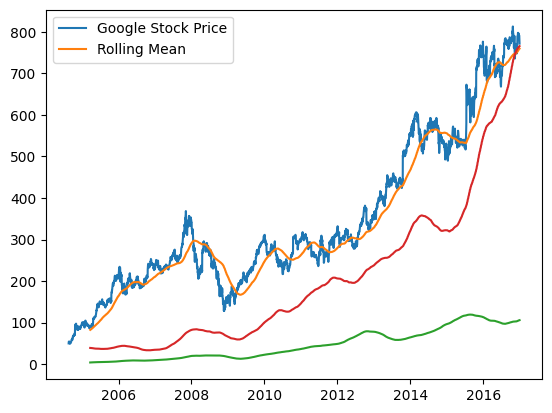

In [13]:
# this allows plots to be rendered in the notebook
%matplotlib inline 

# We import matplotlib into Python
import matplotlib.pyplot as plt


# We plot the Google stock data
plt.plot(all_stocks['google_stock_adj_close'])

# We plot the rolling mean ontop of our Google stock data
plt.plot(rollingMean)
plt.legend(['Google Stock Price', 'Rolling Mean'])
plt.show()